# Turbulence Index

- TI is computed on **13 asset classes** from Bloomberg, internally.
- Quiet = cross-asset **correlations and magnitudes look normal** (no systemic stress).
- Turbulent = **elevated dispersion + unusual move sizes**, often several assets at once.
- After a long calm stretch, a flip to turbulent **tends to persist**.
- Stance: quiet → constructive, **add on weakness**, light hedges. Turbulent → **cut risk, don't chase**, stay flexible.

This notebook implements the public **Kritzman / Chow Mahalanobis turbulence** on a 13-ETF proxy book, then a **regime overlay** that follows those tactical rules — not another formula or DeMark overlay.

`d_t = (r_t - mu_{t-1})' * inv(Sigma_{t-1}) * (r_t - mu_{t-1})`


In [1]:
%matplotlib inline

import sys
from pathlib import Path

_ROOT = Path.cwd() if (Path.cwd() / "Data_Handling.py").exists() else Path.cwd().parent
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2
import yfinance as yf


## Config

Weekly TI (matches their "Nth week in a row" language). Covariance uses only **past** weeks (no lookahead).

13 liquid ETFs as stand-ins for the undisclosed 13 classes: US large/small/tech, EAFE, EM, duration, IG/HY credit, USD, gold, silver, oil, broad commodities.


In [2]:
START = "2015-01-01"
END = None  # through latest available

ASSETS = {
    "US_large": "SPY",
    "US_small": "IWM",
    "US_tech": "QQQ",
    "EAFE": "EFA",
    "EM": "EEM",
    "UST_long": "TLT",
    "IG_credit": "LQD",
    "HY_credit": "HYG",
    "USD": "UUP",
    "Gold": "GLD",
    "Silver": "SLV",
    "Oil": "USO",
    "Broad_cmdty": "DBC",
}

TICKERS = list(ASSETS.values())
N_ASSETS = len(TICKERS)
assert N_ASSETS == 13

COV_WEEKS = 156            # 3y rolling covariance (min 52)
RIDGE = 1e-6               # stabilize Sigma inverse
TURB_PCT = 0.80            # rolling 3y percentile (diagnostic)
CHI2_P = 0.95              # theoretical Mahalanobis threshold
INDEX_CUT = 1.25           #  bars: quiet ~0.5-1.2, purple starts ~1.3
SEVERE_CUT = 2.50          # April/August-style spikes on their 0-7 scale
PERSIST_WEEKS = 2          # extra de-risk weeks after a severe spike only

# Strategy (Friday close, hold through next week)
EQUITY = "SPY"
SAFE = "IEF"               # intermediate Treasuries as the de-risk sleeve
W_EQUITY_QUIET = 0.80      # invested, but do not chase
W_EQUITY_QUIET_DIP = 1.00  # add on weakness (notes: prefer dips vs spikes)
W_EQUITY_MILD = 0.50       # index >= 1.25 (Nov-style one-week caution)
W_EQUITY_SEVERE = 0.25     # index >= 2.5 (April-style systemic week)
DIP_WEEKLY = -0.02         # "add on weakness": SPY week <= -2%
COST_BPS = 5               # round-trip friction on weight change

print(f"{N_ASSETS} assets: {TICKERS}")


13 assets: ['SPY', 'IWM', 'QQQ', 'EFA', 'EEM', 'TLT', 'LQD', 'HYG', 'UUP', 'GLD', 'SLV', 'USO', 'DBC']


## Download daily closes, resample to weekly


In [3]:
need = list(dict.fromkeys(TICKERS + [EQUITY, SAFE]))
raw = yf.download(need, start=START, end=END, auto_adjust=True, progress=False)

if isinstance(raw.columns, pd.MultiIndex):
    close = raw["Close"].copy()
else:
    close = raw[["Close"]].copy()
    close.columns = need[:1]

close = close.dropna(how="all").ffill()
weekly = close.resample("W-FRI").last().dropna(how="any")
rets = np.log(weekly / weekly.shift(1)).dropna()

X = rets[TICKERS]
print(f"weeks={len(X)}  {X.index.min().date()} -> {X.index.max().date()}")
print(X.tail(3).round(4))


weeks=611  2015-01-09 -> 2026-09-18
Ticker         SPY     IWM     QQQ     EFA     EEM     TLT     LQD     HYG  \
Date                                                                         
2026-09-04  0.0011  0.0009  0.0035  0.0058  0.0230 -0.0043 -0.0040 -0.0018   
2026-09-11 -0.0077 -0.0243 -0.0057 -0.0153 -0.0126 -0.0164 -0.0111 -0.0071   
2026-09-18 -0.0009 -0.0141  0.0091 -0.0163 -0.0120  0.0047  0.0036 -0.0009   

Ticker         UUP     GLD     SLV     USO     DBC  
Date                                                
2026-09-04 -0.0036 -0.0052 -0.0033  0.0903  0.0354  
2026-09-11 -0.0004 -0.0199 -0.0288  0.0872  0.0387  
2026-09-18  0.0113  0.0060  0.0307 -0.0070 -0.0070  


## Mahalanobis turbulence (causal)

For each week t: estimate mu, Sigma on the prior `COV_WEEKS` weeks, then score this week's return vector. Asset **contributions** show which markets drove the spike (silver / SPX in the Jan 17 note).


In [4]:
def rolling_turbulence(returns: pd.DataFrame, window: int, ridge: float):
    vals = returns.to_numpy(dtype=np.float64)
    n, k = vals.shape
    d = np.full(n, np.nan)
    contrib = np.full((n, k), np.nan)
    min_obs = min(window, 52)
    eye = np.eye(k)

    for t in range(min_obs, n):
        hist = vals[max(0, t - window):t]  # strictly past
        mu = hist.mean(axis=0)
        centered = hist - mu
        sigma = (centered.T @ centered) / max(len(hist) - 1, 1)
        sigma = sigma + ridge * eye
        try:
            inv = np.linalg.inv(sigma)
        except np.linalg.LinAlgError:
            inv = np.linalg.pinv(sigma)
        z = vals[t] - mu
        mahal = inv @ z
        d[t] = float(z @ mahal)
        contrib[t] = z * mahal  # sums to d[t]

    ti = pd.Series(d, index=returns.index, name="turbulence")
    contrib_df = pd.DataFrame(contrib, index=returns.index, columns=returns.columns)
    return ti, contrib_df


ti, contrib = rolling_turbulence(X, COV_WEEKS, RIDGE)
ti_index = ti / N_ASSETS  #  scale: E[d/N] ≈ 1 when returns are normal
chi2_cut = chi2.ppf(CHI2_P, df=N_ASSETS)
chi2_cut_idx = chi2_cut / N_ASSETS

# Rolling 3y percentile of *past* TI only (causal). Expanding ranks bury
# 2020 in the sample and make later years look quieter than weekly flag.
past_rank = pd.Series(np.nan, index=ti.index)
vals = ti.to_numpy()
for i in range(COV_WEEKS, len(vals)):
    if np.isnan(vals[i]):
        continue
    hist = vals[i - COV_WEEKS:i]
    hist = hist[~np.isnan(hist)]
    if len(hist) < 52:
        continue
    past_rank.iloc[i] = float((hist < vals[i]).mean())

# Published chart is week-by-week: a bar is purple or blue on THAT week only.
chart_turb = ti_index >= INDEX_CUT
raw_turb = chart_turb | (ti > chi2_cut) | (past_rank >= TURB_PCT)

# Overlay persist: after a SEVERE spike, stay de-risked a couple of weeks
# even if the next bars print blue (commentary, not the chart coloring).
severe = ti_index >= SEVERE_CUT
overlay = chart_turb.copy()
for lag in range(1, PERSIST_WEEKS):
    overlay = overlay | severe.shift(lag, fill_value=False)

ti_df = pd.DataFrame({
    "turbulence": ti,
    "index": ti_index,
    "percentile": past_rank,
    "chart_turbulent": chart_turb,
    "turbulent": overlay,
}).dropna(subset=["turbulence"])

print(f"chi2 {CHI2_P:.0%} cutoff: d={chi2_cut:.2f}  index={chi2_cut_idx:.2f}")
print(f"chart cut {INDEX_CUT}: {int(ti_df['chart_turbulent'].sum())} / {len(ti_df)} weeks")
print(ti_df.tail(8).round(3))


chi2 95% cutoff: d=22.36  index=1.72
chart cut 1.25: 159 / 559 weeks
            turbulence  index  percentile  chart_turbulent  turbulent
Date                                                                 
2026-07-31       8.401  0.646       0.321            False      False
2026-08-07      18.686  1.437       0.776             True       True
2026-08-14       4.026  0.310       0.051            False      False
2026-08-21      10.751  0.827       0.462            False      False
2026-08-28       7.228  0.556       0.237            False      False
2026-09-04       9.500  0.731       0.385            False      False
2026-09-11       7.399  0.569       0.244            False      False
2026-09-18       6.154  0.473       0.147            False      False


## What the index is saying now


Week ending 2026-09-18: index=0.47  raw d=6.15  hist pct=14.7%  regime=QUIET

Asset contributions this week (positive = unusual vs history):
Ticker
UUP    1.455
SLV    0.847
DBC    0.778
LQD    0.770
SPY    0.736
QQQ    0.724
EFA    0.570
EEM    0.553
IWM    0.342
HYG    0.098
GLD   -0.011
USO   -0.222
TLT   -0.486


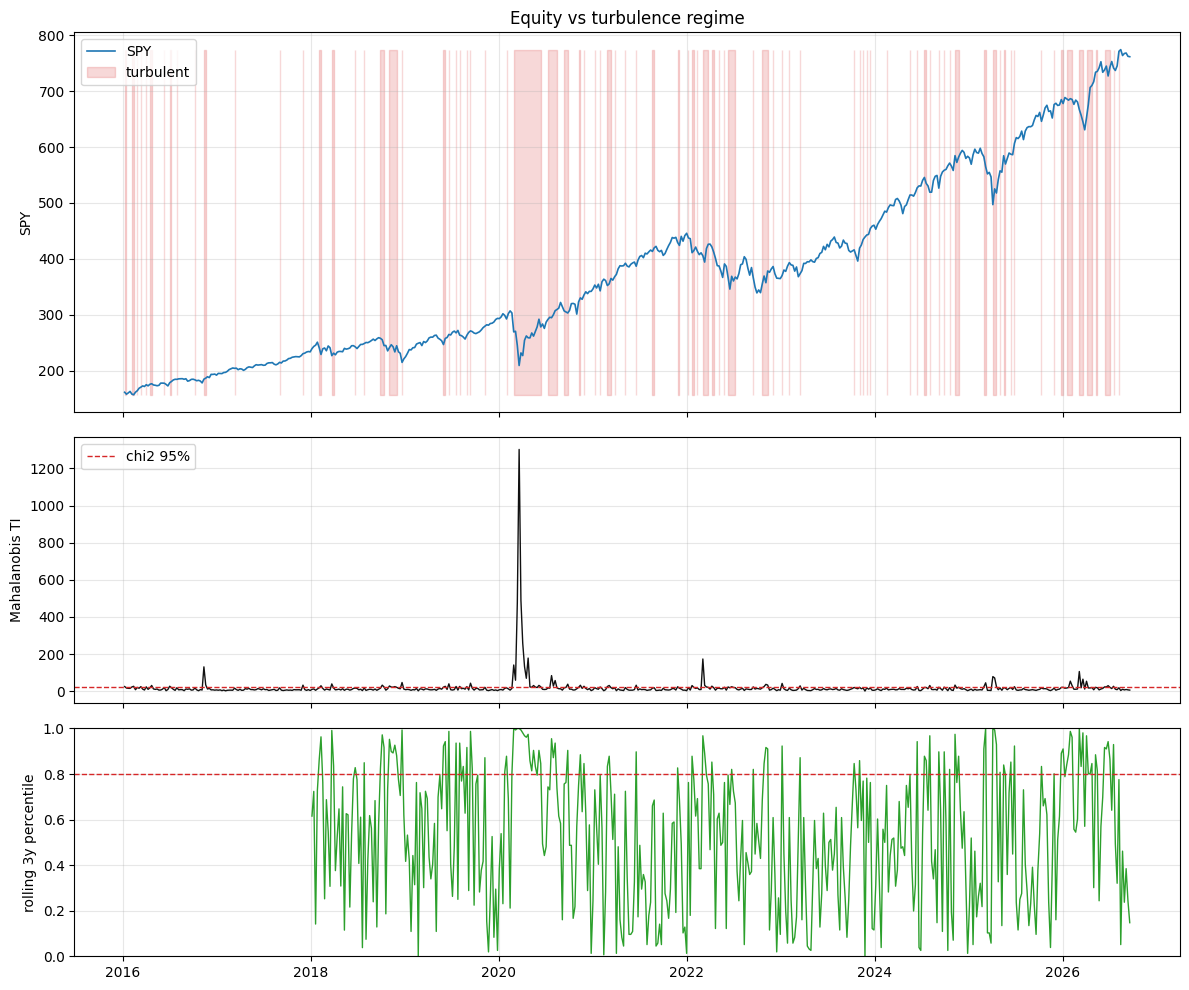

In [5]:
last = ti_df.index[-1]
state = "TURBULENT" if bool(ti_df.loc[last, "turbulent"]) else "QUIET"
print(
    f"Week ending {last.date()}: index={ti_df.loc[last, 'index']:.2f}  "
    f"raw d={ti_df.loc[last, 'turbulence']:.2f}  "
    f"hist pct={ti_df.loc[last, 'percentile']:.1%}  regime={state}"
)

top = contrib.loc[last].sort_values(ascending=False)
print("\nAsset contributions this week (positive = unusual vs history):")
print(top.round(3).to_string())

spy = weekly[EQUITY].reindex(ti_df.index)
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True, gridspec_kw={"height_ratios": [2, 1.4, 1.2]})

axes[0].plot(spy.index, spy.values, color="#1f77b4", lw=1.2, label=EQUITY)
ymin, ymax = float(spy.min()), float(spy.max())
axes[0].fill_between(
    ti_df.index, ymin, ymax, where=ti_df["chart_turbulent"].to_numpy(),
    color="#d62728", alpha=0.18, label="turbulent",
)
axes[0].set_ylabel(EQUITY)
axes[0].set_title("Equity vs turbulence regime")
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.3)

axes[1].plot(ti_df.index, ti_df["turbulence"], color="#111", lw=1.0)
axes[1].axhline(chi2_cut, color="#d62728", ls="--", lw=1, label=f"chi2 {CHI2_P:.0%}")
axes[1].set_ylabel("Mahalanobis TI")
axes[1].legend(loc="upper left")
axes[1].grid(True, alpha=0.3)

axes[2].plot(ti_df.index, ti_df["percentile"], color="#2ca02c", lw=1.0)
axes[2].axhline(TURB_PCT, color="#d62728", ls="--", lw=1)
axes[2].set_ylabel("rolling 3y percentile")
axes[2].set_ylim(0, 1)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## another-style last-52-weeks bars

Their published series is this scaled index (quiet cluster near 1, April 2025 ~6). Color is **that week only**. Height is **severity** — use it to size the cut, not just on/off.

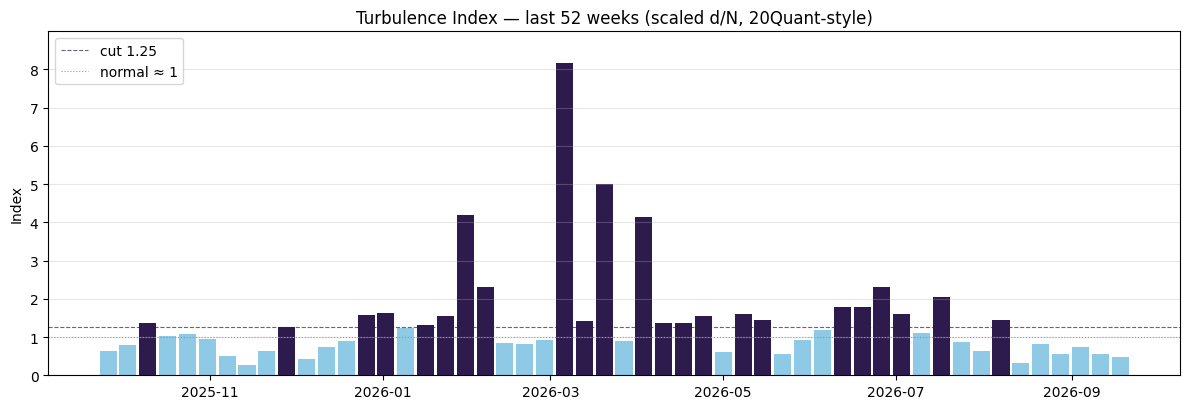

In [ ]:
last52 = ti_df.tail(52)
colors = np.where(last52["chart_turbulent"], "#2d1b4e", "#8ecae6")

fig, ax = plt.subplots(figsize=(12, 4.2))
ax.bar(last52.index, last52["index"], width=6, color=colors, align="center")
ax.axhline(INDEX_CUT, color="#2d1b4e", ls="--", lw=0.8, alpha=0.7, label=f"cut {INDEX_CUT}")
ax.axhline(1.0, color="#999", ls=":", lw=0.8, label="normal ≈ 1")
ax.set_title("Turbulence Index — last 52 weeks (scaled d/N, another-style)")
ax.set_ylabel("Index")
ax.set_ylim(0, max(7, float(last52["index"].max()) * 1.1))
ax.legend(loc="upper left")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Recent weeks vs the anote notes

Notes: Dec 13 and Dec 20 2025 quiet (6th / 7th week); Jan 17 2026 turbulent (metals + SPX).


In [7]:
note_weeks = pd.to_datetime(["2025-12-12", "2025-12-19", "2026-01-16"])
idx = ti_df.index
near = [idx[idx.get_indexer([d], method="nearest")[0]] for d in note_weeks]

lo = min(near) - pd.Timedelta(weeks=8)
hi = max(near) + pd.Timedelta(weeks=2)
view = ti_df.loc[lo:hi].copy()
view["top_driver"] = contrib.reindex(view.index).idxmax(axis=1)
print(view[["index", "percentile", "chart_turbulent", "turbulent", "top_driver"]].round(3).to_string())


            index  percentile  chart_turbulent  turbulent top_driver
Date                                                                
2025-10-17  1.038       0.660            False      False        GLD
2025-10-24  1.090       0.692            False      False        SLV
2025-10-31  0.943       0.622            False      False        LQD
2025-11-07  0.504       0.237            False      False        QQQ
2025-11-14  0.267       0.038            False      False        IWM
2025-11-21  0.638       0.397            False      False        EFA
2025-11-28  1.267       0.801             True       True        SLV
2025-12-05  0.414       0.160            False      False        SLV
2025-12-12  0.739       0.513            False      False        SLV
2025-12-19  0.899       0.615            False      False        SLV
2025-12-26  1.568       0.891             True       True        SLV
2026-01-02  1.629       0.910             True       True        EEM
2026-01-09  1.249       0.788     

If December 2025 prints quiet and silver is the top driver into mid-January, that is the same *shape* as the letters. The binary on/off flag can lag a week or two versus ant because the ETF universe and threshold are ours, not theirs.

## Strategy overlay (what we can recreate)

| Regime | Notes | Implementation |
|---|---|---|
| Quiet (index < 1.25, blue bar) | constructive, add on weakness | 80% SPY; 100% after a ≤ -2% week |
| Mild turbulent (~1.25–2.5, Nov-style) | one-week caution, light hedges | 50% SPY / 50% IEF |
| Severe (≥ 2.5, April-style) | systemic week | 25% SPY / 75% IEF, hold 1 extra week |

Weights are set on Friday from **that week's already-known TI**, then earn **next week's** returns (shift 1). Not another: no DeMark, no strike/gamma, no single-name AI book.


              weeks   CAGR    vol  Sharpe  maxDD  turb_time
TI overlay    558.0  0.095  0.113   0.859 -0.236      0.301
SPY buy&hold  558.0  0.139  0.168   0.859 -0.336      0.301

final NAV  overlay=2.651  SPY=4.040


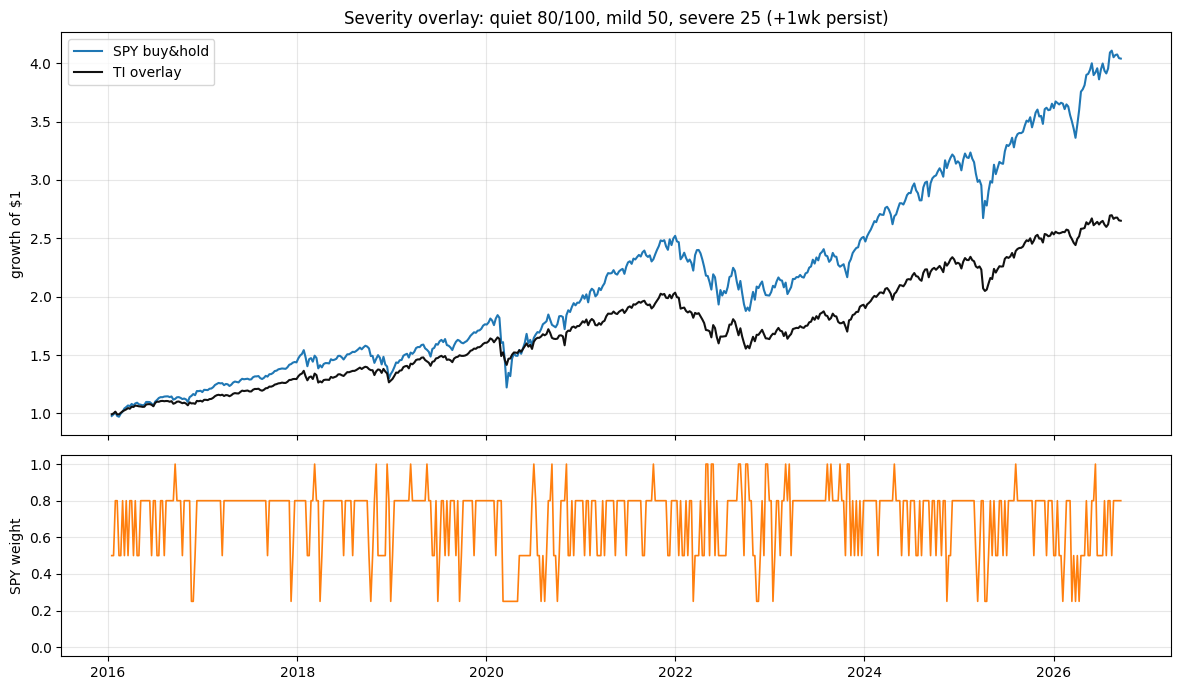

In [8]:
spy_w = rets[EQUITY].reindex(ti_df.index)
safe_w = rets[SAFE].reindex(ti_df.index)
idx = ti_df["index"]
dip = spy_w <= DIP_WEEKLY

w_eq = pd.Series(W_EQUITY_QUIET, index=ti_df.index, dtype=float)
w_eq = w_eq.where(~((~ti_df["chart_turbulent"]) & dip), W_EQUITY_QUIET_DIP)
w_eq = w_eq.where(~(idx >= INDEX_CUT), W_EQUITY_MILD)
w_eq = w_eq.where(~(idx >= SEVERE_CUT), W_EQUITY_SEVERE)
persist = (idx >= SEVERE_CUT)
for lag in range(1, PERSIST_WEEKS):
    persist = persist | (idx.shift(lag) >= SEVERE_CUT)
w_eq = w_eq.where(~(persist & (w_eq > W_EQUITY_MILD)), W_EQUITY_MILD)
w_safe = 1.0 - w_eq

# Trade next week on this week's regime
w_eq_live = w_eq.shift(1)
w_safe_live = w_safe.shift(1)

gross = w_eq_live * spy_w + w_safe_live * safe_w
turnover = w_eq_live.diff().abs().fillna(0.0)
net = gross - turnover * (COST_BPS / 1e4)

bh = spy_w.loc[net.dropna().index]
nav_strat = (1 + net.dropna()).cumprod()
nav_bh = (1 + bh).cumprod()


def _stats(r: pd.Series) -> dict:
    r = r.dropna()
    weeks = len(r)
    ann = 52
    vol = r.std(ddof=1) * np.sqrt(ann)
    eq = (1 + r).cumprod()
    dd = eq / eq.cummax() - 1
    mu = r.mean() * ann
    sharpe = mu / vol if vol else np.nan
    return {
        "weeks": weeks,
        "CAGR": float(eq.iloc[-1] ** (ann / weeks) - 1),
        "vol": float(vol),
        "Sharpe": float(sharpe),
        "maxDD": float(dd.min()),
        "turb_time": float(ti_df.reindex(r.index)["turbulent"].mean()),
    }


stats = pd.DataFrame({
    "TI overlay": _stats(net),
    "SPY buy&hold": _stats(bh),
}).T
print(stats.round(3).to_string())
print(f"\nfinal NAV  overlay={nav_strat.iloc[-1]:.3f}  SPY={nav_bh.iloc[-1]:.3f}")

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(nav_bh.index, nav_bh.values, label="SPY buy&hold", color="#1f77b4")
axes[0].plot(nav_strat.index, nav_strat.values, label="TI overlay", color="#111")
axes[0].set_ylabel("growth of $1")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_title("Severity overlay: quiet 80/100, mild 50, severe 25 (+1wk persist)")

axes[1].plot(w_eq_live.index, w_eq_live.values, color="#ff7f0e", lw=1.2)
axes[1].set_ylabel(f"{EQUITY} weight")
axes[1].set_ylim(-0.05, 1.05)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Read-through

Use TI as a **risk regime**, not an alpha model:

- High TI + metals dominating contributions → do not chase SLV/GLD (Jan 17 note).
- High TI + equities dominating → cut equity beta, keep duration as the ballast.
- Long quiet streak + ugly SPY week → treat as positioning, not a crash, unless TI itself breaks higher.

This will **not** match another week-by-week: different universe, no Bloomberg, no DeMark, no options structure. It *does* give the same *kind* of information their Core letters use.
